In [4]:
!pip install "numpy<2" --force-reinstall

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 24.8 MB/s eta 0:00:00m eta 0:00:010:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.1
    Uninstalling numpy-2.5.1:
      Successfully uninstalled numpy-2.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [ ]:
import os, math
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    f_regression,
    mutual_info_classif,
    mutual_info_regression,
    VarianceThreshold
)


sns.set(style="whitegrid")

print("Libraries installed successfully..")

Libraries installed successfully..


## EDA Processing

In [ ]:
def tabular_pipeline(
    file_path, 
    target_col=None, 
    task_type="auto", 
    method="hybrid", 
    k=20, 
    variance_threshold=0.0, 
    random_state=42
):
    """
    Unified Tabular Data Pipeline: EDA, Preprocessing, Feature Engineering, and Feature Selection.
    """

    # =========================================================
    # 1. TABULAR EDA
    # =========================================================
    def perform_tabular_eda(file_path):
        print(f"\n[ROUTE] Successfully sent to Tabular EDA.")
        print("\n")
        print(f"-> Processing data file: '{os.path.basename(file_path)}'")
        print("\n\n")

        # Structural & Shape Assessment
        try:
            df = pd.read_csv(
                file_path,
                skipinitialspace=True,
                encoding="utf-8",
                on_bad_lines="skip",
                low_memory=False
            )
        except UnicodeDecodeError:
            df = pd.read_csv(
                file_path,
                encoding="latin1",
                on_bad_lines="skip",
                low_memory=False
            )
        
        print(f"The shape of the dataset: {df.shape}")
        print(df.head())
        print(df.tail())
        print(df.sample(5))

        print("\n")
        # Quality & Cleanliness
        missing = pd.DataFrame({
            "Missing": df.isnull().sum(),
            "Percentage": df.isnull().mean() * 100
        })

        print(missing.sort_values("Percentage", ascending=False))
        print(f"Duplicate Values: {df.duplicated().sum()}")
        
        plt.figure(figsize=(10, 6))
        sns.heatmap(df.isnull(), cbar=False)
        plt.title('Missing Values Heatmap')
        plt.show()

        numeric_columns = df.select_dtypes(include=['number'])

        categorical_cols = [
            col for col in df.select_dtypes(include=['object', 'category']).columns
            if df[col].nunique() <= 15
        ]

        high_cardinality_cols = [
            col for col in df.select_dtypes(include=['object', 'category']).columns
            if df[col].nunique() > 15
        ]

        print("\n")
        # Univariate Analysis for numerical Columns
        print("Central Tendency: ")
        for col in df.select_dtypes(include=['number']).columns:
            mean_val = df[col].mean()
            median_val = df[col].median()
            mode_val = df[col].mode()
            mode_value = mode_val.iloc[0] if not mode_val.empty else np.nan
            skew_val = df[col].skew()
            kurtosis_val = df[col].kurt()
            print(f"\nColumn: '{col}'")
            print(f"  -> Mean:   {mean_val:.2f}")
            print(f"  -> Median: {median_val:.2f}")
            print(f"  -> Mode:   {mode_value}")
            print(f"  -> skew:   {skew_val}")
            print(f"  -> Kurtosis:   {kurtosis_val}")
            print(df[col].describe())

        print("\n")
        # Univariate Analysis for Categorical Columns
        small_cat_cols = categorical_cols[:20]
        for col in small_cat_cols:
            print(f"\n--- Analysis for {col} ---")
            print("Frequency Counts:")
            print(df[col].value_counts())

            print("Percentages:")
            print(df[col].value_counts(normalize=True) * 100)

            # Visualization
            plt.figure(figsize=(6, 3))
            sns.countplot(data=df, x=col)
            plt.title(f'Univariate Analysis of {col}')
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.show()

        print("\n")
        # Bivariate Analysis
        # ---- Correlation Matrix
        if not numeric_columns.empty:
            correlation_matrix = numeric_columns.corr()
            plt.figure(figsize=(12, 10))
            sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1.5, linecolor='yellow')
            plt.title('Correlation Heatmap')
            plt.show()

        print('\n')
        # ---- MultiCollinearity
        if len(numeric_columns.columns) > 1:
            vif_df = numeric_columns.fillna(numeric_columns.median())
            vif_df = vif_df.loc[:, vif_df.var() > 0]

            if len(vif_df) > 5000:
                vif_df = vif_df.sample(n=5000, random_state=42)
                print("(VIF calculated using a random sample of 5,000 rows for speed calculations)")

            try:
                vif_data = pd.DataFrame()
                vif_data['features'] = vif_df.columns
                vif_data['VIF'] = [variance_inflation_factor(vif_df.values, i) for i in range(len(vif_df.columns))]
                print(vif_data.sort_values(by="VIF", ascending=False))
            except Exception as e:
                print(f"Could not calculate VIF: {e}")
        else:
            print("Not enough numeric fields to compute MultiCollinearity.")

        print("\n")
        for col in numeric_columns.columns:
            plt.figure(figsize=(12, 4))

            # Histogram
            plt.subplot(1, 2, 1)
            sns.histplot(df[col], kde=True)
            plt.title(f'{col} Distribution')

            # Boxplot
            plt.subplot(1, 2, 2)
            sns.boxplot(x=df[col])
            plt.title(f'{col} Boxplot')

            plt.tight_layout()
            plt.show()

        return df

    # =========================================================
    # 2. TABULAR PREPROCESSING
    # =========================================================
    def tabular_preprocessing(df):
        df = df.copy()

        # -----------------------------
        # 1. Type Handling
        # -----------------------------
        for col in df.columns:
            if df[col].dtype == 'object':
                try:
                    df[col] = pd.to_numeric(df[col])
                except:
                    df[col] = df[col].astype('category')

        # -----------------------------
        # 2. Missing Value Handling
        # -----------------------------
        num_cols = df.select_dtypes(include=['number']).columns
        cat_cols = df.select_dtypes(include=['category', 'object']).columns

        for col in num_cols:
            df[col].fillna(df[col].median(), inplace=True)

        for col in cat_cols:
            df[col].fillna("Unknown", inplace=True)

        # -----------------------------
        # 3. Outlier Capping (IQR)
        # -----------------------------
        for col in num_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            df[col] = np.clip(df[col], lower, upper)

        # -----------------------------
        # 4. Encoding (One-Hot for low cardinality)
        # -----------------------------
        low_card_cols = [col for col in cat_cols if df[col].nunique() <= 10]

        df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

        # -----------------------------
        # 5. Scaling (Standardization)
        # -----------------------------
        scaler = StandardScaler()
        df[num_cols] = scaler.fit_transform(df[num_cols])

        print("Preprocessing Completed")
        return df, scaler

    # =========================================================
    # 3. FEATURE ENGINEERING
    # =========================================================
    def tabular_feature_engineering(df):
        df = df.copy()

        num_cols = df.select_dtypes(include=['number']).columns

        # -----------------------------
        # 1. Log Transform (Skew Handling)
        # -----------------------------
        for col in num_cols:
            if df[col].skew() > 1:
                df[col] = np.log1p(df[col])

        # -----------------------------
        # 2. Interaction Features
        # -----------------------------
        if len(num_cols) >= 2:
            df["interaction_feature"] = df[num_cols[0]] * df[num_cols[1]]

        # -----------------------------
        # 3. Binning Example (if applicable)
        # -----------------------------
        for col in num_cols[:2]:  # limit to avoid explosion
            df[f"{col}_bin"] = pd.qcut(df[col], q=4, labels=False, duplicates='drop')

        # -----------------------------
        # 4. Remove Highly Correlated Features
        # -----------------------------
        corr_matrix = df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        drop_cols = [col for col in upper.columns if any(upper[col] > 0.9)]
        df.drop(columns=drop_cols, inplace=True)

        print(" Feature Engineering Completed")
        return df

    # =========================================================
    # 4. FEATURE SELECTION PIPELINE
    # =========================================================
    def feature_selection_pipeline(
        X: pd.DataFrame,
        y: pd.Series,
        task_type: str = "auto",
        method: str = "hybrid",
        k: int = 20,
        variance_threshold: float = 0.0,
        random_state: int = 42
    ):
        # --- Step 1: Infer Task Type ---
        if task_type == "auto":
            if y.nunique() < 20 and y.dtype in ["int64", "object", "category"]:
                task_type = "classification"
            else:
                task_type = "regression"

        # --- Step 2: Variance Threshold ---
        vt = VarianceThreshold(threshold=variance_threshold)
        X_vt = vt.fit_transform(X)
        retained_cols = X.columns[vt.get_support()]
        X = pd.DataFrame(X_vt, columns=retained_cols)

        # --- Step 3: Filter Methods ---
        if method in ["filter", "hybrid"]:
            if task_type == "classification":
                score_func = mutual_info_classif
            else:
                score_func = mutual_info_regression

            selector = SelectKBest(score_func=score_func, k=min(k, X.shape[1]))
            X_filtered = selector.fit_transform(X, y)
            selected_cols_filter = X.columns[selector.get_support()]

        # --- Step 4: Embedded Methods ---
        if method in ["embedded", "hybrid"]:
            if task_type == "classification":
                model = RandomForestClassifier(random_state=random_state)
            else:
                model = RandomForestRegressor(random_state=random_state)

            model.fit(X, y)
            importances = pd.Series(model.feature_importances_, index=X.columns)

            selected_cols_embedded = importances.nlargest(min(k, len(importances))).index

        # --- Step 5: Combine Methods ---
        if method == "filter":
            selected_features = list(selected_cols_filter)
        elif method == "embedded":
            selected_features = list(selected_cols_embedded)
        else:  # hybrid
            selected_features = list(
                set(selected_cols_filter).intersection(set(selected_cols_embedded))
            )
            if len(selected_features) < max(5, k // 4):
                selected_features = list(
                    set(selected_cols_filter).union(set(selected_cols_embedded))
                )[:k]

        X_selected = X[selected_features]
        return selected_features, X_selected

    # =========================================================
    # 5. PIPELINE EXECUTION
    # =========================================================
    print("\n[PIPELINE] Starting Tabular Data Processing Pipeline...\n")

    raw_df = perform_tabular_eda(file_path)

    preprocessed_df, scaler = tabular_preprocessing(raw_df)

    engineered_df = tabular_feature_engineering(preprocessed_df)

    # Split feature matrix (X) and target variable (y) if target_col specified
    if target_col and target_col in engineered_df.columns:
        X = engineered_df.drop(columns=[target_col])
        y = engineered_df[target_col]
        
        selected_features, X_selected = feature_selection_pipeline(
            X, y,
            task_type=task_type,
            method=method,
            k=k,
            variance_threshold=variance_threshold,
            random_state=random_state
        )
    else:
        print("\n[INFO] Target column omitted or not found — skipping feature selection.")
        X_selected = engineered_df
        selected_features = list(engineered_df.columns)
        y = None

    print("\n[PIPELINE COMPLETE]")
    print(f"Final Feature Shape: {X_selected.shape}")

    return {
        "X": X_selected,
        "y": y,
        "scaler": scaler,
        "selected_features": selected_features
    }

In [ ]:

def image_pipeline(file_path, img_size=(128, 128), n_components=50):

    # =========================================================
    # 1. IMAGE EDA (your logic, slightly modularized)
    # =========================================================
    def image_eda(file_path):

        print(f"\n[EDA] Processing: {os.path.basename(file_path)}")

        image_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.webp')

        image_paths, labels = [], []

        # --- Scan ---
        for root, _, files in os.walk(file_path):
            for f in files:
                if f.lower().endswith(image_ext):
                    p = os.path.join(root, f)
                    image_paths.append(p)
                    labels.append(os.path.basename(os.path.dirname(p)))

        print(f"Images: {len(image_paths)} | Classes: {len(set(labels))}")
        if not image_paths:
            return None

        # --- Containers ---
        widths, heights, ratios, channels, formats = [], [], [], [], []
        corrupted = []

        brightness, contrast, sparsity = [], [], []
        hist = np.zeros(256)

        ch_sum = np.zeros(3)
        ch_sq = np.zeros(3)
        pixel_count = 0

        # --- Loop ---
        for p in image_paths:
            try:
                with Image.open(p) as img:
                    formats.append(img.format)
                    w, h = img.size
                    widths.append(w); heights.append(h)
                    ratios.append(w/h if h else 0)
                    channels.append(len(img.getbands()))

                img_cv = cv2.imread(p)
                if img_cv is None:
                    continue

                img_f = img_cv.astype(np.float32)
                h, w, c = img_f.shape
                n = h*w

                pixel_count += n

                for i in range(c):
                    ch_sum[i] += img_f[:,:,i].sum()
                    ch_sq[i] += (img_f[:,:,i]**2).sum()

                brightness.append(img_f.mean())
                contrast.append(img_f.std())

                sparsity.append((img_f==0).sum()/(h*w*c)*100)

                hist += np.histogram(img_cv.flatten(), bins=256, range=(0,256))[0]

            except:
                corrupted.append(p)

        # --- Stats ---
        print("\nFormats:", Counter(formats))
        print("Channels:", Counter(channels))
        print("Corrupted:", len(corrupted))

        if pixel_count:
            mean = ch_sum/pixel_count
            std = np.sqrt(ch_sq/pixel_count - mean**2)

            print("\nChannel Stats:")
            for i in range(len(mean)):
                print(f"Channel {i}: Mean={mean[i]:.3f}, Std={std[i]:.3f}")

            print("\nDataset Stats:")
            print(f"Brightness: {np.mean(brightness):.2f}")
            print(f"Contrast: {np.mean(contrast):.2f}")
            print(f"Sparsity: {np.mean(sparsity):.2f}%")

        # --- Visualization ---
        fig, ax = plt.subplots(2,3, figsize=(16,9))

        cnt = Counter(labels)
        ax[0,0].bar(cnt.keys(), cnt.values())
        ax[0,0].set_title("Class Distribution")

        ax[0,1].scatter(widths, heights)
        ax[0,1].set_title("Resolution")

        sns.kdeplot(ratios, ax=ax[0,2], fill=True)
        ax[0,2].set_title("Aspect Ratio")

        ax[1,0].bar(range(256), hist)
        ax[1,0].set_title("Pixel Histogram")

        ax[1,1].scatter(brightness, contrast)
        ax[1,1].set_title("Brightness vs Contrast")

        sns.kdeplot(sparsity, ax=ax[1,2], fill=True)
        ax[1,2].set_title("Sparsity")

        plt.tight_layout()
        plt.show()

        return image_paths, labels
    # =========================================================
    # 2. IMAGE PREPROCESSING
    # =========================================================
    def preprocess_images(image_paths):
        processed_images = []
        valid_paths = []

        for path in tqdm(image_paths, desc="Preprocessing Images"):
            try:
                img = cv2.imread(path)
                if img is None:
                    continue

                img = cv2.resize(img, img_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = img / 255.0  # normalization

                processed_images.append(img)
                valid_paths.append(path)

            except:
                continue

        return np.array(processed_images), valid_paths

    # =========================================================
    # 3. FEATURE ENGINEERING (basic image transforms)
    # =========================================================
    def feature_engineering(images):
        features = []

        for img in images:
            gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

            # simple handcrafted features
            mean = np.mean(gray)
            std = np.std(gray)
            edges = cv2.Canny(gray, 100, 200)
            edge_density = np.sum(edges > 0) / edges.size

            features.append([mean, std, edge_density])

        return np.array(features)

    # =========================================================
    # 4. FEATURE EXTRACTION (flatten + PCA)
    # =========================================================
    def feature_extraction(images):
        n_samples = images.shape[0]

        flat = images.reshape(n_samples, -1)

        scaler = StandardScaler()
        flat_scaled = scaler.fit_transform(flat)

        pca = PCA(n_components=min(n_components, flat_scaled.shape[1]))
        reduced = pca.fit_transform(flat_scaled)

        return reduced, scaler, pca

    # =========================================================
    # 5. FEATURE SELECTION (same philosophy as tabular)
    # =========================================================
    def feature_selection(X, y):
        # remove low variance
        vt = VarianceThreshold(0.01)
        X_vt = vt.fit_transform(X)

        # embedded selection
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_vt, y)

        importances = model.feature_importances_
        idx = np.argsort(importances)[::-1][:min(20, len(importances))]

        return X_vt[:, idx], idx

    # =========================================================
    # 6. PIPELINE EXECUTION
    # =========================================================
    print("\n[PIPELINE] Starting Image Processing Pipeline...\n")

    image_paths, labels = image_eda()

    images, valid_paths = preprocess_images(image_paths)

    # align labels
    labels = [os.path.basename(os.path.dirname(p)) for p in valid_paths]
    labels = pd.Series(labels).astype("category").cat.codes

    engineered_features = feature_engineering(images)

    extracted_features, scaler, pca = feature_extraction(images)

    # combine features
    X_combined = np.hstack([engineered_features, extracted_features])

    X_selected, selected_idx = feature_selection(X_combined, labels)

    print("\n[PIPELINE COMPLETE]")
    print(f"Final Feature Shape: {X_selected.shape}")

    return {
        "X": X_selected,
        "y": labels,
        "scaler": scaler,
        "pca": pca,
        "selected_features_idx": selected_idx
    }

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier, HistGradientBoostingRegressor


def train_eval_pipeline(
    pipeline_output: dict,
    task_type: str = "auto",       # "classification", "regression", or "auto"
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Unified ML Training, Evaluation, and Interpretation Pipeline.
    Supports outputs from both tabular_pipeline and image_pipeline.
    """
    print("\n[PIPELINE] Starting Model Training & Evaluation Phase...\n")

    # =========================================================
    # 1. EXTRACT AND VALIDATE DATA
    # =========================================================
    X = pipeline_output.get("X")
    y = pipeline_output.get("y")

    if X is None or y is None:
        raise ValueError("The pipeline output dictionary must contain non-null 'X' and 'y' keys.")

    # Standardize types to numpy/pandas
    if isinstance(X, pd.DataFrame):
        feature_names = list(X.columns)
        X_data = X.values
    else:
        feature_names = [f"feature_{i}" for i in range(X.shape[1])]
        X_data = np.array(X)

    y_data = np.array(y)

    # Convert continuous float targets to categorical integers if needed
    if y_data.dtype.kind in ['O', 'S', 'U']:
        y_data = pd.Series(y_data).astype("category").cat.codes.values

    # Determine Task Type (Classification vs Regression)
    if task_type == "auto":
        unique_targets = len(np.unique(y_data))
        if unique_targets <= 20 and y_data.dtype.kind in ['i', 'b', 'u']:
            task_type = "classification"
        else:
            task_type = "regression"

    print(f"Detected Task Type: '{task_type.upper()}' across {X_data.shape[0]} samples and {X_data.shape[1]} features.")

    # Train-Test Split
    stratify = y_data if task_type == "classification" and len(np.unique(y_data)) > 1 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=test_size, random_state=random_state, stratify=stratify
    )

    # =========================================================
    # 2. MODEL SELECTION & TRAINING WITH LOSS
    # =========================================================
    print("\n--- Training Model & Tracking Loss ---")

    if task_type == "classification":
        # HistGradientBoosting allows tracking loss iteratively
        model = HistGradientBoostingClassifier(
            max_iter=100,
            early_stopping=True,
            random_state=random_state
        )
        model.fit(X_train, y_train)

        # Retrieve training loss history
        if hasattr(model, 'train_score_'):
            plt.figure(figsize=(8, 4))
            plt.plot(model.train_score_, label="Training Score/Loss Iteration")
            plt.title("Training Loss / Score Progression")
            plt.xlabel("Boosting Iterations")
            plt.ylabel("Score")
            plt.grid(True)
            plt.legend()
            plt.show()

    else:
        model = HistGradientBoostingRegressor(
            max_iter=100,
            early_stopping=True,
            random_state=random_state
        )
        model.fit(X_train, y_train)

        if hasattr(model, 'train_score_'):
            plt.figure(figsize=(8, 4))
            plt.plot(model.train_score_, label="Training Loss Iteration")
            plt.title("Training Loss Progression")
            plt.xlabel("Boosting Iterations")
            plt.ylabel("Score")
            plt.grid(True)
            plt.legend()
            plt.show()

    # =========================================================
    # 3. EVALUATION & PREDICTIONS
    # =========================================================
    print("\n--- Model Evaluation on Test Data ---")
    y_pred = model.predict(X_test)
    metrics = {}

    if task_type == "classification":
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)

        # Log Loss (if probabilities can be computed)
        try:
            y_proba = model.predict_proba(X_test)
            loss_val = log_loss(y_test, y_proba)
        except Exception:
            y_proba = None
            loss_val = np.nan

        metrics = {
            "Accuracy": acc,
            "Weighted Precision": prec,
            "Weighted Recall": rec,
            "Weighted F1-Score": f1,
            "Test Log Loss": loss_val
        }

        print(f"Accuracy:            {acc:.4f}")
        print(f"Weighted Precision:  {prec:.4f}")
        print(f"Weighted Recall:     {rec:.4f}")
        print(f"Weighted F1-Score:   {f1:.4f}")
        print(f"Test Log Loss:       {loss_val:.4f}")
        
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, zero_division=0))

        # Confusion Matrix Plot
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

    else: # Regression
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        metrics = {
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "R2 Score": r2
        }

        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root MSE (RMSE):          {rmse:.4f}")
        print(f"Mean Absolute Error (MAE):{mae:.4f}")
        print(f"R² Score:                 {r2:.4f}")

        # Prediction vs Actual Plot
        plt.figure(figsize=(7, 5))
        plt.scatter(y_test, y_pred, alpha=0.6, color='b')
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        plt.title('Actual vs Predicted Values')
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.show()

    # =========================================================
    # 4. INTERPRETATION & FEATURE IMPORTANCE
    # =========================================================
    print("\n--- Model Interpretation ---")
    
    # Train a fast tree surrogate to extract feature importances for interpretation
    if task_type == "classification":
        surrogate = RandomForestClassifier(n_estimators=50, random_state=random_state)
    else:
        surrogate = RandomForestRegressor(n_estimators=50, random_state=random_state)

    surrogate.fit(X_train, y_train)
    importances = surrogate.feature_importances_

    # Plot Top Features
    top_n = min(15, len(feature_names))
    sorted_idx = np.argsort(importances)[::-1][:top_n]
    
    plt.figure(figsize=(10, 5))
    plt.barh([feature_names[i] for i in sorted_idx][::-1], importances[sorted_idx][::-1], color='teal')
    plt.title(f'Top {top_n} Feature Importances')
    plt.xlabel('Importance Score')
    plt.show()

    print("\n[EVALUATION COMPLETE]")

    return {
        "model": model,
        "metrics": metrics,
        "y_pred": y_pred,
        "y_test": y_test,
        "feature_importances": dict(zip(feature_names, importances))
    }

Analyzing file: Handwritten-a-z (Detected extension: )
 System Auto-Detection: Image File.

[ROUTE] Successfully sent to Image EDA.
-> Processing image file: 'Handwritten-a-z'
Total Images: 37
Total Classes: 2

Format Distribution:
Counter({'JPEG': 37})

Unique Dimensions:
{(1200, 1600), (1600, 1200)}

Channel Distribution:
Counter({3: 37})

Corrupted Images: 0

Width Range: Min=1200, Max=1600, Avg=1372.97
Height Range: Min=1200, Max=1600, Avg=1427.03

Computing global pixel statistics and distributions...

 CHANNEL-WISE CALCULATED NORM VALUES:
  Channel 0 -> Mean: 165.3343 | Std Dev: 23.3048
  Channel 1 -> Mean: 163.7324 | Std Dev: 26.2000
  Channel 2 -> Mean: 161.9204 | Std Dev: 25.0416

 DATASET CHARACTERISTICS SUMMARY:
  Average Global Brightness: 163.66
  Average Global Contrast: 24.05
  Average Image Sparsity (Black Pixels %): 0.00%

Rendering visualization dashboard...


/tmp/ipykernel_15908/3541320095.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(label_counts.keys(), rotation=45, ha='right')


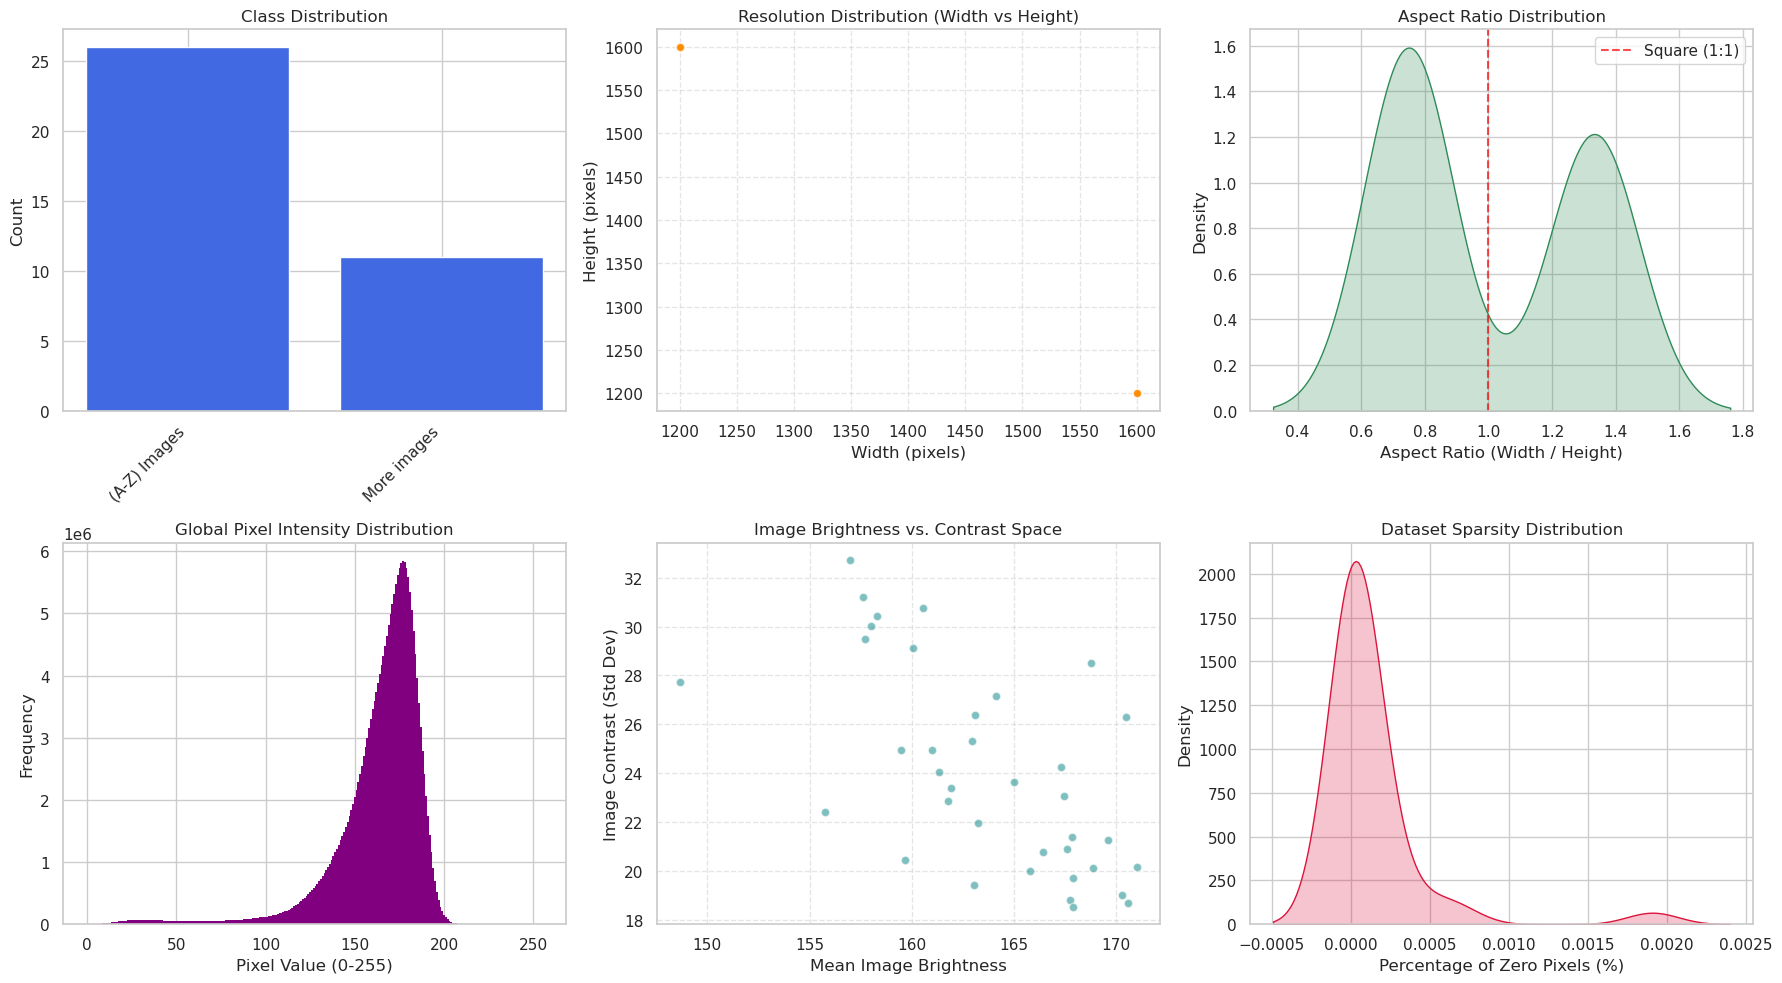

In [ ]:
import os
from pathlib import Path


def auto_detect_and_route_dataset(file_path, target_col=None, task_type="auto"):
    """
    Auto-detects dataset type (tabular vs image), routes to the respective 
    processing pipeline, and executes the ML training/evaluation phase.
    """
    if not os.path.exists(file_path):
        print(f"Error: The file or folder at '{file_path}' does not exist.")
        return None

    path_obj = Path(file_path)
    file_extension = path_obj.suffix.lower()
    
    tabular_extensions = {'.csv', '.tsv', '.xlsx', '.xls', '.json'}
    image_extensions = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.webp'}

    print(f"Analyzing path: {os.path.basename(file_path)} (Extension: '{file_extension}')")

    pipeline_output = None

    # =========================================================
    # 1. ROUTING & DATA PROCESSING PHASE
    # =========================================================
    if path_obj.is_file() and file_extension in tabular_extensions:
        print("\n[ROUTER] System Auto-Detection: Tabular / Structured Data File.")
        pipeline_output = tabular_pipeline(
            file_path=file_path,
            target_col=target_col,
            task_type=task_type
        )

    elif path_obj.is_dir():
        print("\n[ROUTER] System Auto-Detection: Image Directory Dataset.")
        pipeline_output = image_pipeline(file_path=file_path)

    elif path_obj.is_file() and file_extension in image_extensions:
        print("\n[ROUTER] System Auto-Detection: Single Image File / Image Directory.")
        # Pass parent directory if a single image file path is given
        pipeline_output = image_pipeline(file_path=str(path_obj.parent))

    else:
        print(f"\n[ERROR] Unsupported file extension or directory structure: '{file_extension}'")
        return None

    # =========================================================
    # 2. MACHINE LEARNING TRAINING & EVALUATION PHASE
    # =========================================================
    if pipeline_output is not None and pipeline_output.get("y") is not None:
        print("\n[ROUTER] Routing dataset into the ML Training Pipeline...")
        ml_results = train_eval_pipeline(
            pipeline_output=pipeline_output,
            task_type=task_type
        )
        return {
            "data_pipeline_output": pipeline_output,
            "ml_results": ml_results
        }
    else:
        print("\n[WARNING] ML training skipped. Target column 'y' is missing or dataset is empty.")
        return {
            "data_pipeline_output": pipeline_output,
            "ml_results": None
        }


if __name__ == "__main__":

    # Example 1: Route an Image Dataset Folder
    print("=" * 50)
    print("RUNNING IMAGE DATASET ROUTE")
    print("=" * 50)
    results_image = auto_detect_and_route_dataset("Handwritten-a-z")
    
    print("\n" + "=" * 50 + "\n")

    # Example 2: Route a Tabular CSV Dataset File
    print("=" * 50)
    print("RUNNING TABULAR DATASET ROUTE")
    print("=" * 50)
    # results_tabular = auto_detect_and_route_dataset("data.csv", target_col="target")